# Baseline model — Logistic Regression on `papers_fe.parquet`

**Author:** SF — **Status:** final. Built and validated against one specific file,
`data/processed/papers_fe.parquet`, as it exists today. This notebook is fully
self-contained — every transformation is written inline, with no dependency on a shared
module that could change for unrelated work later. Once run through end-to-end, it is not
expected to need further changes.

## Scope

This is the **generalized (pooled) baseline** — all 6 use cases pooled together, split at
the row level. It answers *"how well does a `LogisticRegression` predict relevance on more
papers from research questions it has already seen data from."* It does **not** test
whether this generalizes to a brand-new, seventh use case — that is a materially different
question (Leave-One-Use-Case-Out), asked and answered elsewhere in this project, not here.
§7 says more about why that distinction matters for how to read this notebook's numbers.

## Feature set, and why

The model is `LogisticRegression` on: **`PCA(50, whiten=True)` of the 8,704-dim embedding
block** (three concatenated models — Jasper, Qwen3-4B, Qwen3-8B) **+ all 33 engineered
non-embedding features** (lexical/BM25 term-overlap, per-model cosine-similarity-to-brief,
basic metadata). This combination was chosen from a prior comparison, on this exact file,
of every reasonable alternative:

| Feature set | ROC-AUC |
|---|---|
| 6 cosine-similarity columns alone | 0.681 |
| All 33 non-embedding features together | 0.796 |
| Full 8,704-dim embedding alone | 0.844 |
| PCA(embeddings, 30) alone | 0.845 |
| PCA(embeddings, 50) alone | 0.858 |
| PCA(embeddings, 100) alone | 0.870 |
| **PCA(embeddings, 50) + all non-embedding features** | **0.871 (best)** |

PCA(50) was picked over PCA(100) despite PCA(100) alone scoring marginally higher in that
comparison, because combined with the non-embedding features, 50 components already
matched the best result found — fewer components at the same performance is the more
defensible choice, not a compromise.

## Structure — this order is deliberate, not incidental

1. **Data health check** — what's actually in the file: shape, balance, missingness,
   duplicates, embedding sanity. Findings only, no fixes.
2. **Data cleaning** — the fixes §1 justifies. Only *deterministic* ones happen here.
3. **Train/test split** — before any statistic is estimated from the data.
4. **Standardisation & dimensionality reduction** — every fitted transform, fit only on
   training rows, at the correct point after the split.
5. **Train the model.**
6. **Test the model** — one holdout score.
7. **Scope & limitations.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, fbeta_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## Parameters

Fixed values for this specific file and this specific model — not a config surface meant
to anticipate a different dataset.


In [2]:
DATA_PATH = "../../data/processed/papers_fe.parquet"

TARGET_COL = "triage_label"
POSITIVE_LABEL = "positive"
NEGATIVE_LABELS = ["negative"]

USE_CASE_COL = "use_case_key"
GROUP_COL = "first_author"

NON_EMBEDDING_FEATURE_COLS = [
    "lex_n_tokens", "lex_bm25_obj", "lex_bm25_prob", "lex_bm25_must", "lex_bm25_nice", "lex_bm25_dom",
    "lex_rank_bm25_obj", "lex_rank_bm25_prob", "lex_rank_bm25_must", "lex_rank_bm25_nice", "lex_rank_bm25_dom",
    "lex_overlap_must_n", "lex_overlap_must_frac", "lex_rank_overlap_must",
    "lex_overlap_nice_n", "lex_overlap_nice_frac", "lex_rank_overlap_nice",
    "lex_overlap_excl_n", "lex_overlap_excl_frac",
    "lex_overlap_must_per_1k", "lex_overlap_nice_per_1k", "lex_has_exclude_terms",
    "cos_brief_jasper", "rank_cos_brief_jasper",
    "cos_brief_qwen4b", "rank_cos_brief_qwen4b",
    "cos_brief_qwen8b", "rank_cos_brief_qwen8b",
    "year", "paper_age", "has_abstract", "n_authors", "citation_count",
]

PCA_N_COMPONENTS = 50
N_SPLITS_OUTER = 5   # first fold's test rows -> final_holdout (~20%), touched once in §6
N_SPLITS_INNER = 5   # validation folds within train_pool, §5
RANDOM_STATE = 0


## 1. Data health check

Read-only findings about the file as it actually is. Nothing here is a fix — fixes happen
in §2, once a finding here justifies one.


In [3]:
df = pd.read_parquet(DATA_PATH)
EMBEDDING_COLS = [c for c in df.columns if c.startswith("emb_")]
non_embedding_cols = [c for c in df.columns if not c.startswith("emb_")]

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]:,} columns from {DATA_PATH}")
print(f"{len(EMBEDDING_COLS):,} embedding columns ({EMBEDDING_COLS[0]} .. {EMBEDDING_COLS[-1]})")
print(f"{len(non_embedding_cols)} non-embedding columns")

missing_expected = [c for c in NON_EMBEDDING_FEATURE_COLS if c not in df.columns]
if missing_expected:
    raise ValueError(
        f"Expected non-embedding feature column(s) not found in this file: {missing_expected}. "
        f"The schema has changed since this notebook was built - stop and check before continuing."
    )


Loaded 1,848 rows x 8,742 columns from ../../data/processed/papers_fe.parquet
8,704 embedding columns (emb_jasper_0000 .. emb_qwen8b_4095)
38 non-embedding columns


### 1.1 Target and use-case balance

In [4]:
print("triage_label:")
display(df[TARGET_COL].value_counts(dropna=False))
print("\nuse_case_key:")
display(df[USE_CASE_COL].value_counts())


triage_label:


triage_label
positive    1065
negative     783
pass           0
Name: count, dtype: int64


use_case_key:


use_case_key
solar_leo           358
soil_microbiome     357
ner                 312
carbon_capture      295
tech_forecasting    264
cement_binders      262
Name: count, dtype: int64

**Finding.** No `pass` rows and no nulls in `triage_label` — this file is already
filtered to reviewed positive/negative papers only. 1,065 positive / 783 negative
(57.6% / 42.4%) pooled; use-case sizes range 262–358 rows, a ~1.4x spread.


### 1.2 Missingness audit

In [5]:
missing = df[non_embedding_cols].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Non-embedding columns with any missing values:")
display(missing.to_frame("n_missing").assign(pct=lambda d: (d["n_missing"] / len(df)).round(3)))

n_missing_emb = int(np.isnan(df[EMBEDDING_COLS].to_numpy()).sum())
print(f"\nMissing values across all {len(EMBEDDING_COLS):,} embedding columns: {n_missing_emb}")


Non-embedding columns with any missing values:


,n_missing,pct
lex_overlap_excl_n,917,0.496
lex_overlap_excl_frac,917,0.496
citation_count,202,0.109
n_authors,25,0.014
paper_age,8,0.004
year,8,0.004



Missing values across all 8,704 embedding columns: 0


**Finding.** The embedding block has zero missing values. Five non-embedding columns have
real missingness: `lex_overlap_excl_n`/`lex_overlap_excl_frac` (~50%), `citation_count`
(~11%), `n_authors` (~1.4%), `year`/`paper_age` (~0.4%). ~50% missing on the two
exclude-term-overlap columns is large enough to be worth explaining, not just filling —
checked directly below.


In [6]:
print("lex_has_exclude_terms vs. lex_overlap_excl_n missingness:")
display(pd.crosstab(df["lex_has_exclude_terms"], df["lex_overlap_excl_n"].isna(),
                     rownames=["lex_has_exclude_terms"], colnames=["excl_n is NaN"]))


lex_has_exclude_terms vs. lex_overlap_excl_n missingness:


excl_n is NaN,False,True
lex_has_exclude_terms,,
False,0,917
True,931,0


**Hard finding.** The missingness is fully explained: every row where
`lex_has_exclude_terms` is `False` has `lex_overlap_excl_n`/`frac` as `NaN` (917 rows), and
every row where it's `True` has both populated (931 rows) — zero exceptions. This is
**structural**, not missing-at-random: those two columns are only defined when the paper's
use case specifies exclude terms in its brief. For a use case with none, "how many
exclude terms does this paper overlap with" isn't unknown, it's zero by construction. This
determines how the two columns are cleaned in §2, differently from the other three.


### 1.3 Duplicate-row check

In [7]:
n_dup_paper_id = df["paper_id"].duplicated(keep=False).sum()
print(f"Rows sharing an exact paper_id with another row: {n_dup_paper_id} (out of {len(df):,})")


Rows sharing an exact paper_id with another row: 0 (out of 1,848)


**Finding, with a documented gap.** Zero exact-`paper_id` duplicates, as expected —
`paper_id` is constructed to be unique. **This does not check whether the same real paper
appears under a *different* `paper_id` in a different use case** — that check needs a
`title` column, which this file doesn't have (dropped during feature engineering). See §7.


### 1.4 Embedding column sanity

In [8]:
emb_matrix = df[EMBEDDING_COLS].to_numpy()
var = emb_matrix.var(axis=0)
print(f"Embedding columns with exactly zero variance: {int((var == 0).sum())}")
print(f"Embedding columns with variance < 1e-8 (effectively constant): {int((var < 1e-8).sum())}")
print(f"Any non-finite (inf) values: {bool(np.isinf(emb_matrix).any())}")


Embedding columns with exactly zero variance: 0
Embedding columns with variance < 1e-8 (effectively constant): 2


Any non-finite (inf) values: False


**Finding.** No exactly-constant embedding dimensions, no infinities. 2 of 8,704
dimensions are near-constant — `StandardScaler` handles this safely (a variance floor,
not a division by zero), so they contribute approximately nothing to the PCA in §4 without
any special-case handling. Nothing to fix here.


## 2. Data cleaning

Two different fixes, deliberately treated differently:

- **`lex_overlap_excl_n`/`lex_overlap_excl_frac` → fill with 0, now, on the whole
  dataset.** Safe to do *before* the split, unlike everything in §4: filling with 0 isn't a
  statistic estimated from the data (that would have to wait for the split) — it's a fixed
  rule justified by §1.2's finding (`lex_has_exclude_terms=False` ⟺ zero applicable
  exclude terms ⟺ 0 overlap, by construction). It's as safe as computing `paper_age` from
  `year` would be — deterministic and identical regardless of which fold a row lands in.
- **`citation_count`, `n_authors`, `year`, `paper_age` → left as real `NaN`, until §4.**
  Ordinary missing data, not a structural "not applicable" case — the correct fill value
  is a statistic (a median) that depends on which rows are in the training fold, so it's
  fit inside the pipeline in §4, never here.


In [9]:
n_before = df["lex_overlap_excl_n"].isna().sum()
df["lex_overlap_excl_n"] = df["lex_overlap_excl_n"].fillna(0.0)
df["lex_overlap_excl_frac"] = df["lex_overlap_excl_frac"].fillna(0.0)
print(f"lex_overlap_excl_n/frac: {n_before} missing -> {df['lex_overlap_excl_n'].isna().sum()} missing "
      f"(filled with 0, deterministically, pre-split)")

remaining_missing = df[NON_EMBEDDING_FEATURE_COLS].isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(f"\nColumns still carrying real missingness, deferred to §4's fitted imputer: "
      f"{remaining_missing.to_dict()}")


lex_overlap_excl_n/frac: 917 missing -> 0 missing (filled with 0, deterministically, pre-split)

Columns still carrying real missingness, deferred to §4's fitted imputer: {'year': 8, 'paper_age': 8, 'n_authors': 25, 'citation_count': 202}


In [10]:
df = df[df[TARGET_COL].isin([POSITIVE_LABEL, *NEGATIVE_LABELS])].copy()
df["y"] = (df[TARGET_COL] == POSITIVE_LABEL).astype(int)
FEATURE_COLS = EMBEDDING_COLS + NON_EMBEDDING_FEATURE_COLS

print(f"{len(df):,} rows retained (target binarized; §1.1 already confirmed no pass/null rows exist)")
print(f"{len(FEATURE_COLS):,} total feature columns "
      f"({len(EMBEDDING_COLS):,} embedding -> PCA in §4, {len(NON_EMBEDDING_FEATURE_COLS)} non-embedding)")


1,848 rows retained (target binarized; §1.1 already confirmed no pass/null rows exist)
8,737 total feature columns (8,704 embedding -> PCA in §4, 33 non-embedding)


## 3. Train/test split — before anything gets fit

**Nothing before this point has fit a statistic; nothing after this point may fit one
using rows outside its own fold.** §2's cleaning was a fixed rule, safe on the whole
dataset — the scaler and PCA in §4 are not, and are correctly deferred to after this
split.

### 3.1 Outer split — carve out `final_holdout`

`StratifiedGroupKFold(n_splits=5)`, grouped by `first_author` (the same author never
straddles train and test), stratified on a `use_case_key + label` composite (no split
skews toward one use case by chance). Its first fold's test rows become `final_holdout`
(~20%), touched only once, in §6. The rest becomes `train_pool`.


In [11]:
strat_key_outer = df[USE_CASE_COL].astype(str) + "__" + df["y"].astype(str)
outer_cv = StratifiedGroupKFold(n_splits=N_SPLITS_OUTER, shuffle=True, random_state=RANDOM_STATE)
outer_splits = list(outer_cv.split(df, strat_key_outer, groups=df[GROUP_COL]))
train_pool_idx, final_holdout_idx = outer_splits[0]

train_pool = df.iloc[train_pool_idx].reset_index(drop=True)
final_holdout = df.iloc[final_holdout_idx].reset_index(drop=True)

print(f"train_pool: {len(train_pool):,} rows | final_holdout: {len(final_holdout):,} rows "
      f"({len(final_holdout) / len(df):.1%} of the pooled dataset)")
display(pd.concat([
    train_pool[USE_CASE_COL].value_counts(normalize=True),
    final_holdout[USE_CASE_COL].value_counts(normalize=True),
], axis=1, keys=["train_pool", "final_holdout"]).round(3))


train_pool: 1,478 rows | final_holdout: 370 rows (20.0% of the pooled dataset)


,train_pool,final_holdout
use_case_key,,
soil_microbiome,0.194,0.192
solar_leo,0.194,0.195
ner,0.168,0.170
carbon_capture,0.160,0.157
cement_binders,0.142,0.141
tech_forecasting,0.142,0.146


### 3.2 Leakage check on the outer split

In [12]:
overlap_authors = set(train_pool[GROUP_COL]) & set(final_holdout[GROUP_COL])
print(f"Authors present in both train_pool and final_holdout: {len(overlap_authors)} "
      f"(expected 0 - StratifiedGroupKFold guarantees this by construction)")
print("Cross-use-case duplicate-paper check: not possible on this file (no `title` column) - see §7.")


Authors present in both train_pool and final_holdout: 0 (expected 0 - StratifiedGroupKFold guarantees this by construction)
Cross-use-case duplicate-paper check: not possible on this file (no `title` column) - see §7.


### 3.3 Inner split — validation folds within `train_pool`

Same scheme, one level down, computed *within* `train_pool` only — `final_holdout` never
informs this.


In [13]:
strat_key_inner = train_pool[USE_CASE_COL].astype(str) + "__" + train_pool["y"].astype(str)
inner_cv = StratifiedGroupKFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=RANDOM_STATE)
inner_splits = list(inner_cv.split(train_pool, strat_key_inner, groups=train_pool[GROUP_COL]))
print(f"{len(inner_splits)} inner validation folds built within train_pool ({len(train_pool):,} rows)")


5 inner validation folds built within train_pool (1,478 rows)


## 4. Standardisation and dimensionality reduction

Every fitted transformation in this notebook happens here, wrapped in one
`scikit-learn` `Pipeline` with two independently-fit branches — a single `.fit(X_train,
y_train)` call fits everything inside it on the training rows given to it, and nothing
else:

- **Embedding block (8,704 cols) → `StandardScaler` → `PCA(n_components=50,
  whiten=True)`.** Scaling *before* PCA is required, not stylistic: the block concatenates
  three models (Jasper, Qwen3-4B, Qwen3-8B), each with its own raw scale. PCA finds
  directions of maximum variance — fit on the unscaled concatenation, the top components
  would reflect whichever model has the largest raw magnitude, not whichever directions
  are actually informative. `whiten=True` then rescales the 50 retained components to unit
  variance; `PCA` only centers by default, and `LogisticRegression`'s L2 penalty is
  scale-sensitive, so without whitening it would regularize the lower-variance (later)
  components harder than the higher-variance ones, for a reason unrelated to their actual
  predictive value.
- **The 33 non-embedding features → median `SimpleImputer` → `StandardScaler`.** This is
  where `citation_count`/`n_authors`/`year`/`paper_age`'s real missingness (§1.2, left
  untouched in §2) finally gets filled — with a median, which is a statistic, which is why
  it waits until here and is fit on `train_pool`/each inner fold alone.


In [14]:
def build_model_pipeline():
    embedding_branch = Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=PCA_N_COMPONENTS, whiten=True, random_state=RANDOM_STATE)),
    ])
    non_embedding_branch = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    preprocess = ColumnTransformer([
        ("embedding_pca", embedding_branch, EMBEDDING_COLS),
        ("non_embedding", non_embedding_branch, NON_EMBEDDING_FEATURE_COLS),
    ])
    return Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])


def score(y_true, proba_pos, pred):
    return {
        "auc": float(roc_auc_score(y_true, proba_pos)),
        "ap": float(average_precision_score(y_true, proba_pos)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, pred, beta=2, zero_division=0)),
    }


def ranking_metrics(y_true, scores_arr, fractions=(0.10, 0.20), wss_target_recall=0.95):
    y_true = np.asarray(y_true)
    n = len(y_true)
    n_pos = int(y_true.sum())
    order = np.argsort(-np.asarray(scores_arr))
    cum_pos = np.cumsum(y_true[order])
    out = {}
    for frac in fractions:
        k = max(1, int(round(frac * n)))
        out[f"recall_at_{int(frac * 100)}pct"] = float(cum_pos[k - 1] / n_pos)
    target_count = int(np.ceil(wss_target_recall * n_pos))
    cutoff_idx = int(np.searchsorted(cum_pos, target_count, side="left"))
    screened = cutoff_idx + 1
    out["wss_at_95"] = float((n - screened) / n - (1 - wss_target_recall))
    return out


def bootstrap_auc_ci(y_true, scores_arr, n_boot=1000, random_state=0):
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    scores_arr = np.asarray(scores_arr)
    n = len(y_true)
    boot = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_true[idx], scores_arr[idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(lo), float(hi)


## 5. Train the baseline model

**5.1 Validation** — a fresh `build_model_pipeline()` fit per inner fold, so the scaler,
PCA, and imputer are never fit on that fold's own held-back rows.


In [15]:
val_rows = []
for tr_idx, te_idx in inner_splits:
    fold_pipeline = build_model_pipeline()
    fold_train, fold_test = train_pool.iloc[tr_idx], train_pool.iloc[te_idx]
    fold_pipeline.fit(fold_train[FEATURE_COLS], fold_train["y"])

    pos_col = list(fold_pipeline.classes_).index(1)
    proba = fold_pipeline.predict_proba(fold_test[FEATURE_COLS])[:, pos_col]
    pred = fold_pipeline.predict(fold_test[FEATURE_COLS])
    val_rows.append(score(fold_test["y"].to_numpy(), proba, pred))

val_df = pd.DataFrame(val_rows)
print(f"Validation (inner CV, {len(inner_splits)} folds) - mean \u00b1 std")
display(val_df.agg(["mean", "std"]).round(3))


Validation (inner CV, 5 folds) - mean ± std


,auc,ap,recall,f2
mean,0.871,0.886,0.819,0.820
std,0.011,0.011,0.019,0.017


**5.2 Final fit** — one `build_model_pipeline()` fit on the whole of `train_pool`. This
exact fitted object is what §6 scores on `final_holdout`.


In [16]:
final_pipeline = build_model_pipeline()
final_pipeline.fit(train_pool[FEATURE_COLS], train_pool["y"])
pos_col = list(final_pipeline.classes_).index(1)

train_proba = final_pipeline.predict_proba(train_pool[FEATURE_COLS])[:, pos_col]
train_pred = final_pipeline.predict(train_pool[FEATURE_COLS])
train_metrics = score(train_pool["y"].to_numpy(), train_proba, train_pred)
print("Train (in-sample, on train_pool itself)")
display(pd.Series(train_metrics).round(3))

fitted_pca = final_pipeline.named_steps["preprocess"].named_transformers_["embedding_pca"].named_steps["pca"]
cum_var = np.cumsum(fitted_pca.explained_variance_ratio_)
print(f"\nPCA({PCA_N_COMPONENTS}), fit on train_pool's {len(EMBEDDING_COLS):,}-dim embedding block: "
      f"explains {cum_var[-1]:.1%} of that block's variance "
      f"(component 1 alone: {fitted_pca.explained_variance_ratio_[0]:.1%}, "
      f"components 1-10: {cum_var[9]:.1%})")


Train (in-sample, on train_pool itself)


auc       0.906
ap        0.925
recall    0.838
f2        0.841
dtype: float64


PCA(50), fit on train_pool's 8,704-dim embedding block: explains 58.0% of that block's variance (component 1 alone: 9.6%, components 1-10: 39.3%)


## 6. Test the baseline model

`final_pipeline` was fit on `train_pool` only. This is the first and only time
`final_holdout` is used.


In [17]:
holdout_proba = final_pipeline.predict_proba(final_holdout[FEATURE_COLS])[:, pos_col]
holdout_pred = final_pipeline.predict(final_holdout[FEATURE_COLS])
holdout_metrics = score(final_holdout["y"].to_numpy(), holdout_proba, holdout_pred)
holdout_metrics.update(ranking_metrics(final_holdout["y"].to_numpy(), holdout_proba))
ci_lo, ci_hi = bootstrap_auc_ci(final_holdout["y"].to_numpy(), holdout_proba)
holdout_metrics["auc_ci_low"], holdout_metrics["auc_ci_high"] = ci_lo, ci_hi

print("Holdout (final_holdout, touched for the first time just now)")
display(pd.Series(holdout_metrics).round(3))

stage_table = pd.DataFrame({
    "train": {k: train_metrics[k] for k in ["auc", "ap", "recall", "f2"]},
    "validation_mean": {k: val_df[k].mean() for k in ["auc", "ap", "recall", "f2"]},
    "validation_std": {k: val_df[k].std() for k in ["auc", "ap", "recall", "f2"]},
    "holdout": {k: holdout_metrics[k] for k in ["auc", "ap", "recall", "f2"]},
}).T.round(3)
print("\nTrain -> validation -> holdout, side by side")
stage_table


Holdout (final_holdout, touched for the first time just now)


auc                0.867
ap                 0.873
recall             0.779
f2                 0.790
recall_at_10pct    0.160
recall_at_20pct    0.324
wss_at_95          0.180
auc_ci_low         0.829
auc_ci_high        0.902
dtype: float64


Train -> validation -> holdout, side by side


,auc,ap,recall,f2
train,0.906,0.925,0.838,0.841
validation_mean,0.871,0.886,0.819,0.820
validation_std,0.011,0.011,0.019,0.017
holdout,0.867,0.873,0.779,0.790


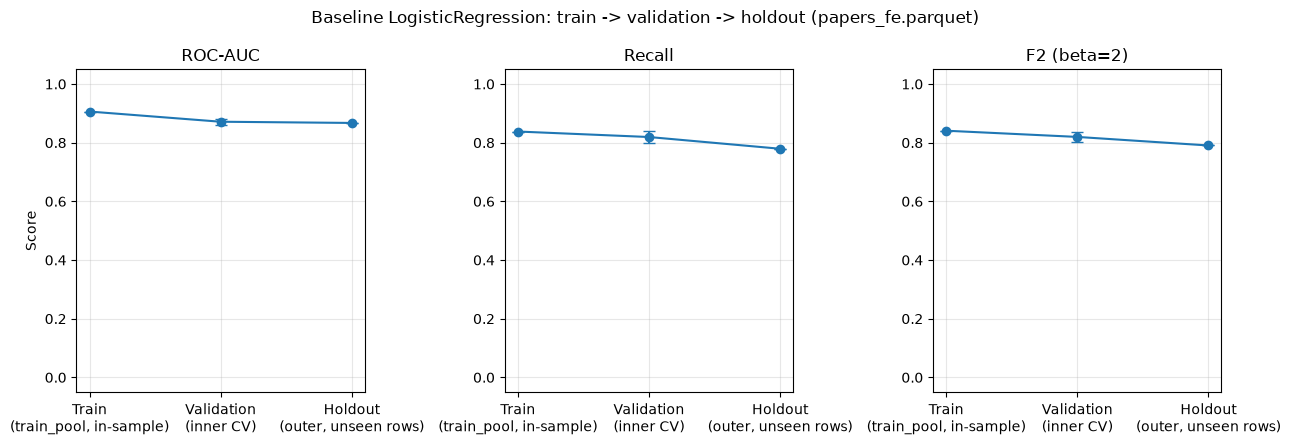

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True)
metrics_map = {"ROC-AUC": "auc", "Recall": "recall", "F2 (beta=2)": "f2"}
stage_labels = ["Train\n(train_pool, in-sample)", "Validation\n(inner CV)", "Holdout\n(outer, unseen rows)"]

for ax, (label, col) in zip(axes, metrics_map.items()):
    means = [train_metrics[col], val_df[col].mean(), holdout_metrics[col]]
    stds = [0, val_df[col].std(), 0]
    ax.errorbar(range(3), means, yerr=stds, marker="o", capsize=4, color="tab:blue")
    ax.set_xticks(range(3))
    ax.set_xticklabels(stage_labels)
    ax.set_title(label)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Score")
fig.suptitle("Baseline LogisticRegression: train -> validation -> holdout (papers_fe.parquet)")
plt.tight_layout()
plt.show()


**Hard finding — train → validation → holdout: 0.906 → 0.871 → 0.867 AUC.** Validation and
holdout sit within one fold's own standard deviation of each other (0.871 ± 0.011 vs.
0.867), and Recall (0.819 vs. 0.779) / F2 (0.820 vs. 0.790) show the same small gap — no
real validation→holdout collapse, exactly as expected when `final_holdout` is a random
slice of the *same* 6 use cases the model trained on, not a new domain (see §7 for why that
distinction matters).

**Hard finding — PCA(50) keeps a majority, not the entirety, of the embedding block's
variance: 58.0%** (component 1 alone: 9.6%; the top 10: 39.3%). A real, substantial
compression (174:1) that still matches this notebook's intro comparison's best result —
the discarded 42% is apparently noise or redundancy the classifier doesn't need, not
signal it's losing.

**Read alongside §7, not instead of it:** these numbers describe how well this model
predicts relevance on more data from research questions it has already seen. They say
nothing about a genuinely new use case — that is a different, harder question, answered
by a different evaluation elsewhere in this project, not by this notebook.


## 7. Scope & limitations

- **This is the pooled/generalized baseline, not a generalization test.**
  `final_holdout` is a random slice of the *same* 6 use cases the model trained on — this
  notebook says how well the model does on more data like what it has already seen, not
  on a genuinely new research question. A colleague's concurrent work found that a pooled
  model can recover `use_case_key` from the embedding at 96% accuracy — worth keeping in
  mind when reading this notebook's headline numbers: some of what looks like "relevance"
  signal may be "which use case is this" signal, which is exactly why a separate
  Leave-One-Use-Case-Out evaluation (elsewhere in this project) is the one that answers
  "will this work on a new use case," not this notebook.
- **Cross-use-case duplicate-paper leakage is unverified on this file.** §1.3/§3.2 could
  only check exact `paper_id` duplication (passes trivially, by construction). The real
  question — whether the same real paper appears under a different `paper_id` in a
  different use case — needs a `title` column, which this file doesn't have.
- **Whether the `rank_*` columns were computed per-use-case or globally across the pooled
  dataset is unconfirmed.** If computed globally, that's a fitted statistic that entered
  this file before it ever reached this notebook, and no split-timing discipline here can
  undo it.
- **`PCA_N_COMPONENTS = 50` and the feature list are specific to this file as it exists
  today.** If the embedding models, their dimensionality, or the engineered feature set
  change in a future version of `papers_fe.parquet`, the comparison in this notebook's
  intro should be re-run before assuming 50 components is still the right choice.
